# 넷플릭스 데이터 분석

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
#차트에서 한글파일 깨질때

import matplotlib.font_manager as fm  # 폰트 관리

!apt-get update -qq         # apt-get 패키지 설치 명령어, -qq : 에러외 메세지 숨기기
!apt-get install fonts-nanum* -qq #나눔글꼴 설치

fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic') #파일 저장되어있는 경로와 이름 설정
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) #폰트설정

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [20]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/netflix_titles.csv')
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [22]:
data.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [23]:
data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [24]:
data['director'] = data['director'].fillna('Unkown')
data['cast'] = data['cast'].fillna('Unkown')
data['country'] = data['country'].fillna('Unkown')

/tmp/ipython-input-3104889301.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data,x='type',palette='Set2')


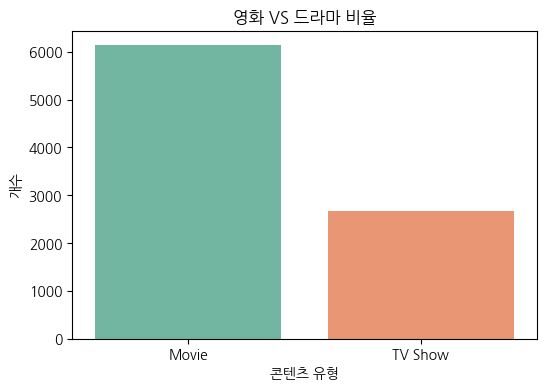

In [25]:
# 영화 vs 드라마
plt.figure(figsize=(6,4))
sns.countplot(data=data,x='type',palette='Set2')
plt.title('영화 VS 드라마 비율')
plt.xlabel('콘텐츠 유형')
plt.ylabel('개수')
plt.show()

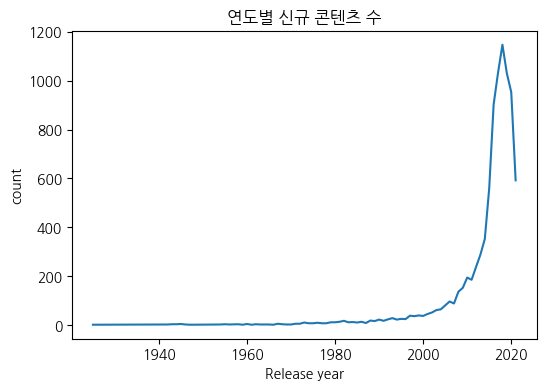

In [30]:
# 연도별 콘텐츠 출시량
data['release_year'] = pd.to_numeric(data['release_year'],errors='coerce')

year_counts = data['release_year'].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.lineplot(x=year_counts.index,y=year_counts.values)
plt.title('연도별 신규 콘텐츠 수')
plt.xlabel('Release year')
plt.ylabel('count')
plt.show()

In [ ]:
#장르 단어 분석 , 콤마로 묶여 있으므로 분리
genre_split = data['listed_in'].str.splot(". ")
all_genres = [g for genres in genre_split.drop]

In [ ]:
# 영화 길이 분포

movie_df = data[data['type']=='Movie'].copy()

movie_df['duration_min'] = movie_df['duration].str.ex

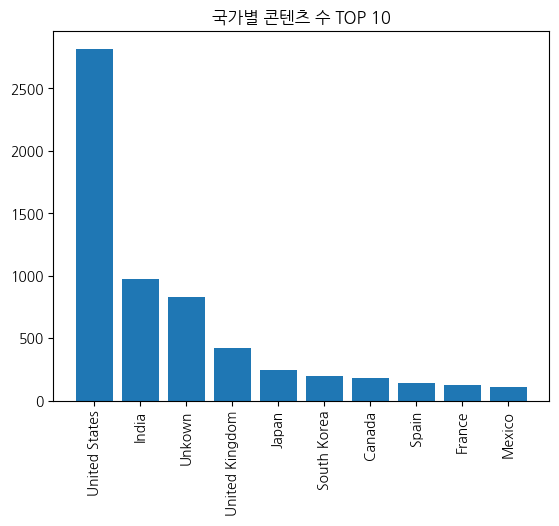

In [33]:
country_counts = data['country'].value_counts().head(10)

plt.bar(country_counts.index,country_counts.values)
plt.title('국가별 콘텐츠 수 TOP 10')
plt.xticks(rotation=90)
plt.show()

# Spotify Tracks 데이터 분석

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/SpotifyFeatures.csv')
data.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [40]:
data.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [41]:
data.isna().sum()

,0
genre,0
artist_name,0
track_name,1
track_id,0
popularity,0
acousticness,0
danceability,0
duration_ms,0
energy,0
instrumentalness,0


In [42]:
data['track_name'] = data['track_name'].fillna('Unkown')

In [45]:
data['artist_name'].values

array(['Henri Salvador', 'Martin & les fées', 'Joseph Williams', ...,
       'Muddy Waters', 'R.LUM.R', 'Mint Condition'], dtype=object)

In [46]:
data['genre'].values

array(['Movie', 'Movie', 'Movie', ..., 'Soul', 'Soul', 'Soul'],
      dtype=object)

In [47]:
print(len(data))
print(data['genre'].nunique())
print(data['artist_name'].nunique())

232725
27
14564


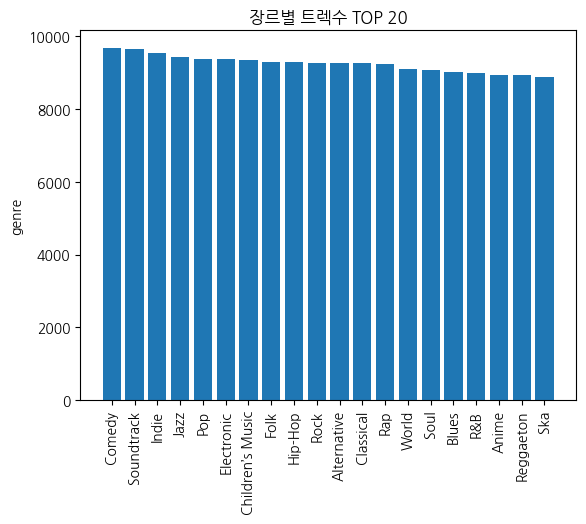

In [56]:
genre_count = data['genre'].value_counts().head(20)

plt.bar(genre_count.index,genre_count.values)
plt.title('장르별 트렉수 TOP 20')
plt.xticks(rotation=90)
plt.ylabel('genre')
plt.show()

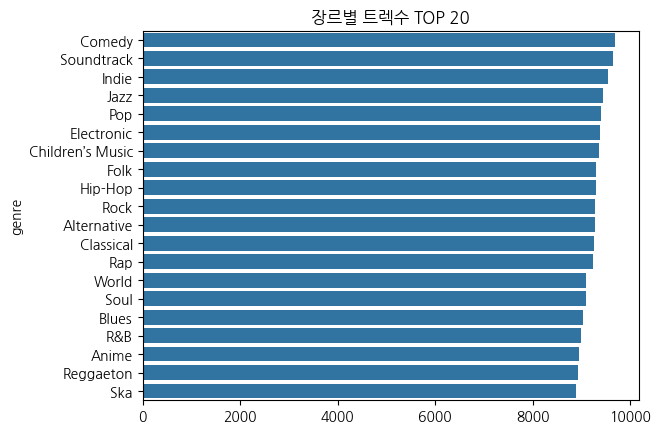

In [57]:
genre_count = data['genre'].value_counts().head(20)

sns.barplot(y=genre_count.index,x=genre_count.values)
plt.title('장르별 트렉수 TOP 20')
plt.ylabel('genre')
plt.show()

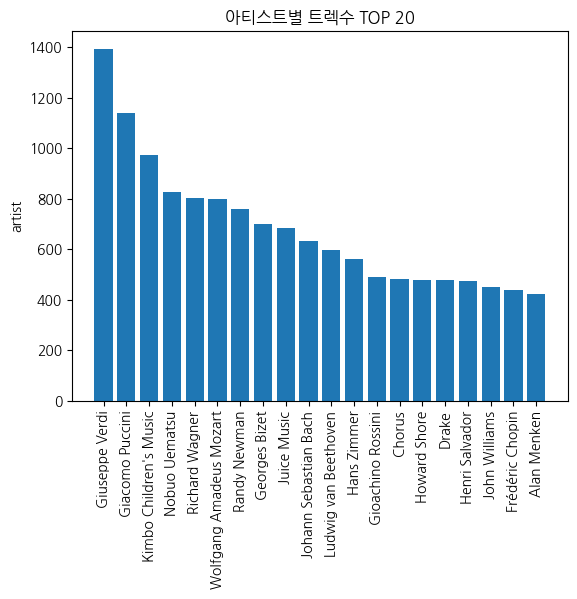

In [58]:
artist_count = data['artist_name'].value_counts().head(20)

plt.bar(artist_count.index,artist_count.values)
plt.title('아티스트별 트렉수 TOP 20')
plt.xticks(rotation=90)
plt.ylabel('artist')
plt.show()

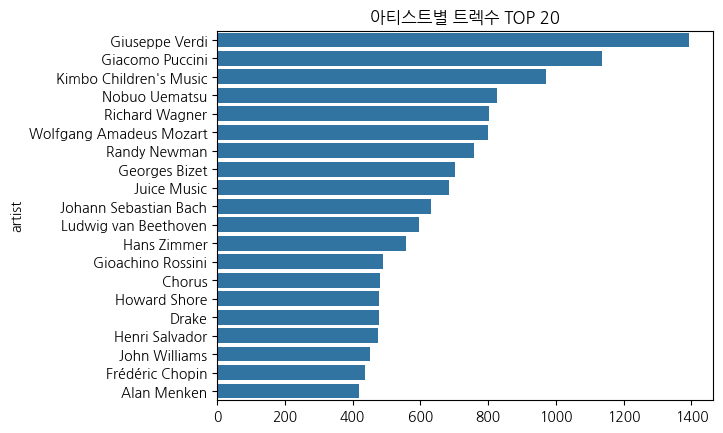

In [59]:
artist_count = data['artist_name'].value_counts().head(20)

sns.barplot(y=artist_count.index,x=artist_count.values)
plt.title('아티스트별 트렉수 TOP 20')
plt.ylabel('artist')
plt.show()

In [61]:
# 가장 인기 높은 곡 TOP 1% 확인

top_tracks = data[data['popularity']>=data['popularity'].quantile(0.99)]
top_tracks

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
671,Alternative,Joji,Sanctuary,3xaugmCyXrVkrDTXbFkMW3,83,0.42200,0.552,180019,0.650,0.000275,C#,0.3720,-7.199,Major,0.1280,167.788,4/4,0.316
672,Alternative,Joji,SLOW DANCING IN THE DARK,0rKtyWc8bvkriBthvHKY8d,81,0.54400,0.515,209274,0.479,0.005980,D#,0.1910,-7.458,Major,0.0261,88.964,4/4,0.284
677,Alternative,Smash Mouth,All Star,3cfOd4CMv2snFaKAnMdnvK,78,0.03190,0.731,200373,0.861,0.000000,B,0.0829,-5.881,Major,0.0323,104.034,4/4,0.780
679,Alternative,Gorillaz,Feel Good Inc.,0d28khcov6AiegSCpG5TuT,77,0.00836,0.818,222640,0.705,0.002330,F#,0.6130,-6.679,Major,0.1770,138.559,4/4,0.772
682,Alternative,Red Hot Chili Peppers,Under the Bridge,3d9DChrdc6BOeFsbrZ3Is0,78,0.05760,0.559,264307,0.345,0.000105,E,0.1410,-13.496,Major,0.0459,84.581,4/4,0.458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221806,Rock,Scorpions,Wind Of Change,3ovjw5HZZv43SxTwApooCM,77,0.37100,0.480,313227,0.535,0.000000,C,0.0929,-10.232,Major,0.0324,75.766,4/4,0.293
221815,Rock,Tom Walker,Leave a Light On,6lOWoTqVnAWXchddtTH31W,81,0.01530,0.586,185863,0.624,0.000002,F,0.1330,-5.946,Major,0.1130,68.976,4/4,0.267
223072,Rock,Noah Kahan,Hurt Somebody (With Julia Michaels),7vA2Y79Q4bBqdzBCfHeGEe,77,0.33800,0.633,168640,0.559,0.000000,F#,0.2620,-5.135,Major,0.3130,114.983,4/4,0.473
223166,Rock,Juanes,La Plata (feat. Lalo Ebratt),7Eso5mURNFprb5PmhOXDlf,78,0.20100,0.762,195493,0.740,0.000000,C#,0.2750,-4.720,Minor,0.2260,167.881,4/4,0.961


In [62]:
top_tracks.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
671,Alternative,Joji,Sanctuary,3xaugmCyXrVkrDTXbFkMW3,83,0.42200,0.552,180019,0.650,0.000275,C#,0.3720,-7.199,Major,0.1280,167.788,4/4,0.316
672,Alternative,Joji,SLOW DANCING IN THE DARK,0rKtyWc8bvkriBthvHKY8d,81,0.54400,0.515,209274,0.479,0.005980,D#,0.1910,-7.458,Major,0.0261,88.964,4/4,0.284
677,Alternative,Smash Mouth,All Star,3cfOd4CMv2snFaKAnMdnvK,78,0.03190,0.731,200373,0.861,0.000000,B,0.0829,-5.881,Major,0.0323,104.034,4/4,0.780
679,Alternative,Gorillaz,Feel Good Inc.,0d28khcov6AiegSCpG5TuT,77,0.00836,0.818,222640,0.705,0.002330,F#,0.6130,-6.679,Major,0.1770,138.559,4/4,0.772
682,Alternative,Red Hot Chili Peppers,Under the Bridge,3d9DChrdc6BOeFsbrZ3Is0,78,0.05760,0.559,264307,0.345,0.000105,E,0.1410,-13.496,Major,0.0459,84.581,4/4,0.458


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


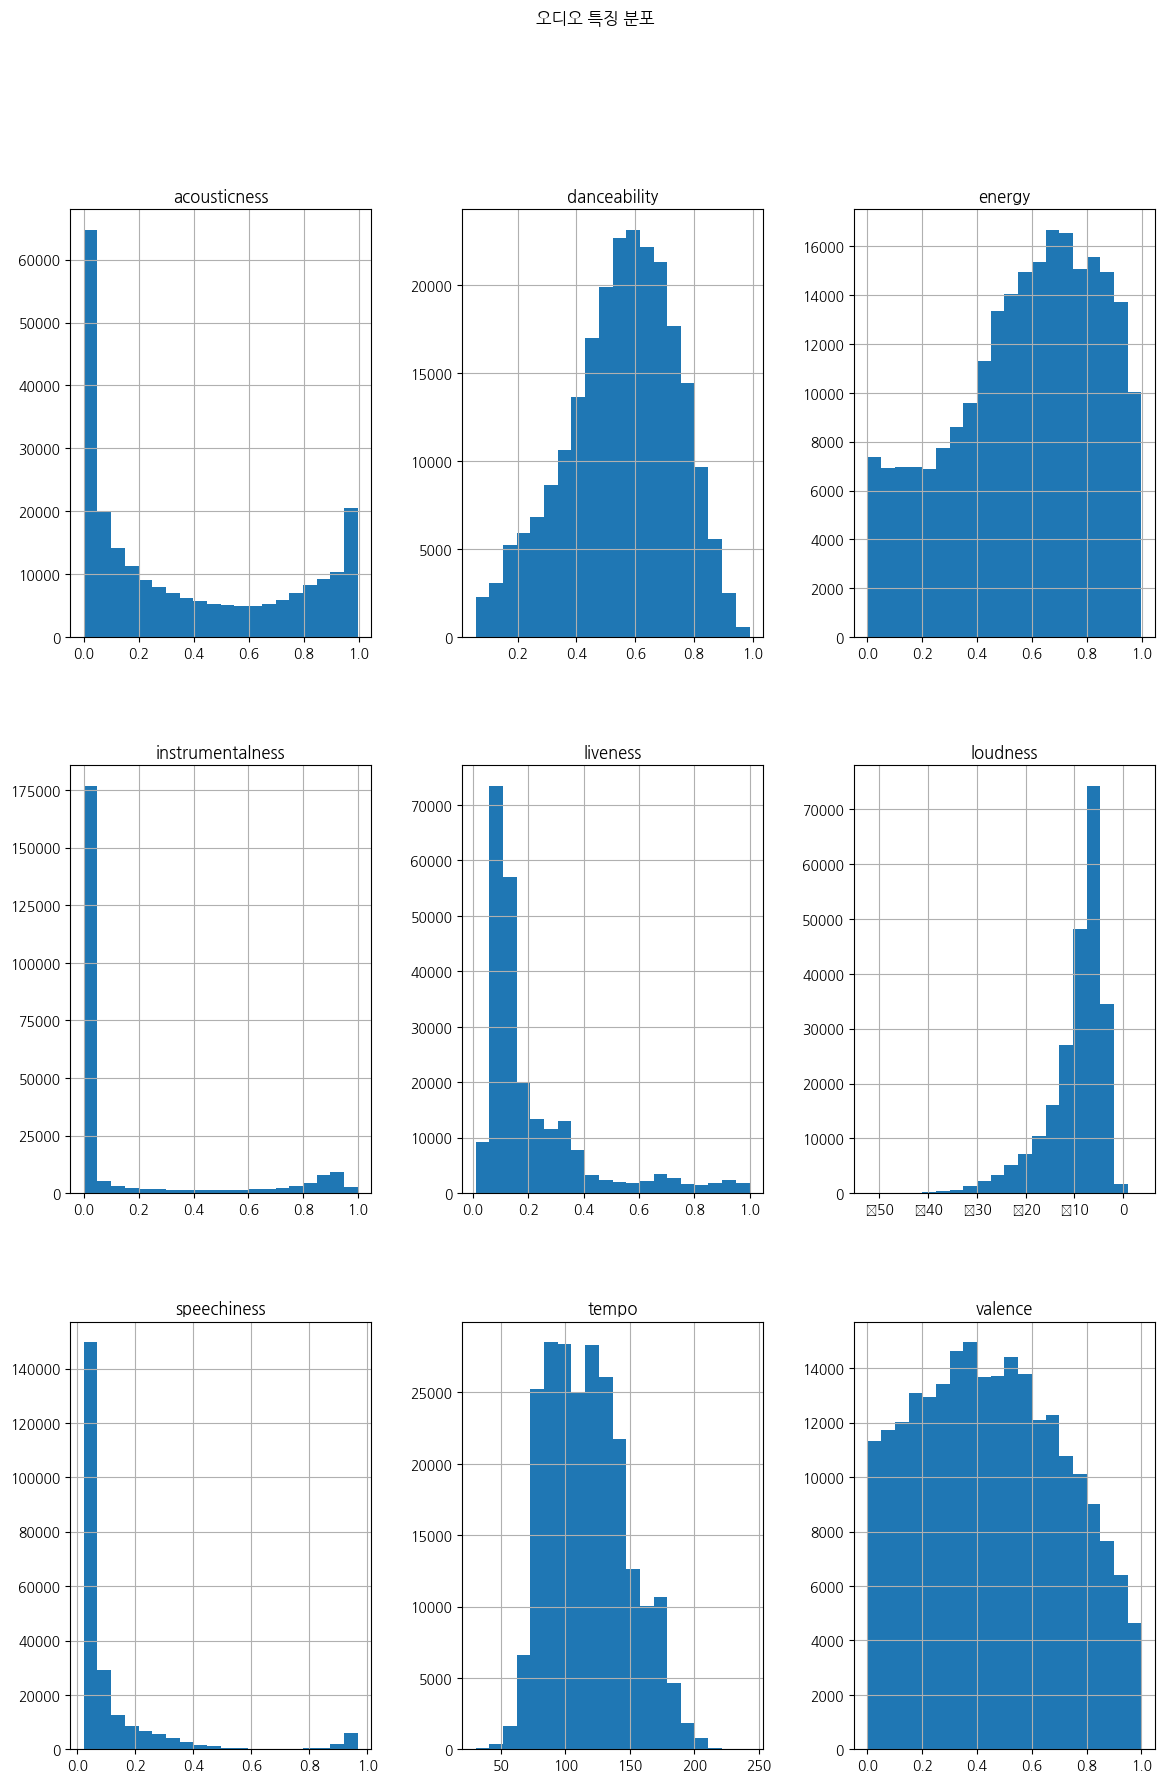

In [64]:
audio_cols = ['acousticness','danceability','energy','instrumentalness','liveness',
              'loudness','speechiness','tempo','valence']

data[audio_cols].hist(figsize=(14,20),bins=20)
plt.suptitle('오디오 특징 분포')
plt.show()